# Country Borders Geometry

In this notebook, we analyze the geometry of European countries in residual-stream embedding space and compare geodesic "on-manifold" steering against linear steering on a relational geographic task ("which country borders Spain to the east?").

Research objective:
> Visualize geometrical organiation of European countries' representations when solving arithmetic geographic questions.
> Comparing geodesic steering against linear steering on a relational task whose answer-side representation forms a 2-D geographic map.

Research questions (RQs):
- **Task performance:** Can the model reliably solve the directional-border task at all?
- **Layer localization:** At which layer and token position is the answer-country variable mediated?
- **Subspace localization:** What's the lowest-dimensional subspace mediating most task-related variance?
- **Manifold localization:** Can we identify a two-dimensional manifold (the Europe map) that mediates the answer country?
- **Steering evaluation:** How does geometric vs linear steering affect output behavior between far countries (e.g. Spain → Russia)?

Our task is to select suitable interpretability methods to answer each RQ. Each RQ is an analysis that employs interpretability tools.
We build that analysis in a modular way to quickly iterate on hyperparameters defined in a config.


## Task performance

First we set up the task and measure whether the model reliably solves it at all. 
The causal model notebook [[link]] demonstrates how to set up tasks.
Here we've already set up the `country_borders` task: 30 European countries × 8 cardinal/intercardinal directions × 4 paraphrase templates, where the model has to retrieve the neighboring country in a given direction.
The task has been set up with a bunch of default configs. The runner config


In [1]:
# Define the baseline config, save and load for printing

# # country_borders task with Gemma 3 27B-PT (pre-trained, non-instruct)

# Convention: the defaults list is the source of truth for analysis steps.
# Each `- analysis/<step>` entry mounts that analysis at `cfg.<step>` (via
# `# @package <step>` in the analysis YAML). Add a top-level `<step>:` block
# only when you need to override fields.

baseline_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_4b_pt
  - /analysis/baseline
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = train
  target_variable: country

baseline:
  visualization:
    figure_format: png
"""


from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

# Save the config overrides
path = save_runner_config(baseline_config_yaml, 'country_borders_baseline_demo')
print(f'Written to {path}\n')

# Load the full hydra config
cfg = load_runner_config('country_borders_baseline_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /workspace/causalab/causalab/configs/runners/demos/country_borders_baseline_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: country_borders
  max_new_tokens: 1
  intervention_metric: string_match
  colormap: viridis
  colormap2: null
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: country
  color_by_dim: 0
  reference_source: empirical
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range: null
    grid_resolution: null
    bin_positions: null
model:
  id: gemma3_4b_pt
  name: google/gemma-3-4b-pt
  device: auto
  dtype: bfloat16
  eager_attn: false
  use_chat_template: false
  model_class: Gemma3ForCausalLM
  slurm:
    gpus: 1
baseline:
  _name_: baseline
  batch_size: 32
  visualization:
    figure_format: png



In [2]:
import os
os.environ["PATH"] = "/root/.local/bin:" + os.environ["PATH"]

In [3]:
# Run the baseline analysis.
#
# Gemma 3 27B-PT is the pre-trained (non-instruct) variant — it completes
# the task's plain "Q: ... A:" templates directly, like Llama-3.1-8B base.
# No chat-template wrapping needed (model config has use_chat_template: false).
import os
import causalab
import subprocess

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_baseline_demo"],
    cwd=project_root,
)

if rc.returncode == 0:
    print("\n\nBaseline analysis ran successfully!")

[2026-05-21 12:36:08,945][__main__][INFO] - === Step: baseline (baseline) ===
[2026-05-21 12:36:12,988][causalab.neural.activations.intervenable_model][INFO] - Registered Gemma3ForCausalLM with pyvene (reusing Gemma2 mappings).
[2026-05-21 12:36:13,027][__main__][INFO] - Running analysis: baseline | target_variable: country
[2026-05-21 12:36:13,046][causalab.analyses.baseline.main][INFO] - Counterfactual change_country: distinguishes country from [] → 1.00 (64/64)
[2026-05-21 12:36:13,060][causalab.analyses.baseline.main][INFO] - Counterfactual change_direction: distinguishes country from [] → 0.00 (0/64)
[2026-05-21 12:36:13,071][causalab.analyses.baseline.main][INFO] - Counterfactual change_template: distinguishes country from [] → 0.00 (0/64)
[2026-05-21 12:36:13,205][causalab.analyses.baseline.main][INFO] - Counterfactual random_counterfactual: distinguishes country from [] → 0.97 (62/64)
[2026-05-21 12:36:13,302][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique 

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 18.69it/s]


[2026-05-21 12:36:25,506][causalab.methods.metric][INFO] - Base model accuracy: 352/960 (36.7%)
[2026-05-21 12:36:25,506][causalab.methods.metric][INFO] - Base model prob accuracy: 18.3%
[2026-05-21 12:36:25,511][causalab.analyses.baseline.main][INFO] - Base accuracy: 36.7%
[2026-05-21 12:36:31,188][causalab.analyses.baseline.main][INFO] - Collected per-example logits: 960 examples, 1 steps each
[2026-05-21 12:36:34,400][causalab.analyses.baseline.main][INFO] - Saved full output distributions: torch.Size([960, 262208])
[2026-05-21 12:36:34,713][causalab.analyses.baseline.main][INFO] - Saved decoded top-10 logits for 960 examples.
[2026-05-21 12:36:35,490][causalab.analyses.baseline.main][INFO] - Saved per-class output distributions: torch.Size([30, 30])
[2026-05-21 12:36:36,052][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/gemma3_4b_pt/baseline/ground_truth_dim0.png
[2026-05-21 12:36:36,052][causalab.analyses.path_steering.path_visualization][INFO] - 

In [4]:
import json
import os

artifact_dir = os.path.join(project_root, cfg.experiment_root, 'baseline')
print(f'Artifact directory: {artifact_dir}\n')
print('Contents:', sorted(os.listdir(artifact_dir)))

Artifact directory: /workspace/causalab/artifacts/country_borders/gemma3_4b_pt/baseline

Contents: ['accuracy.json', 'confusion_heatmap.png', 'counterfactual_sanity.json', 'full_output_dists.safetensors', 'ground_truth_dim0.png', 'metadata.json', 'per_class_output_dists.safetensors', 'test_samples.json', 'top_logits.json', 'train_samples.json']


In [5]:
# Show task samples 

with open(os.path.join(artifact_dir, 'train_samples.json')) as f:
    train_samples = json.load(f)['samples']
print(json.dumps(train_samples[:3], indent=2))

[
  {
    "raw_input": "Q: Which country lies to the north of France?\nA:",
    "raw_output": " Belgium"
  },
  {
    "raw_input": "Q: What country borders France on the north?\nA:",
    "raw_output": " Belgium"
  },
  {
    "raw_input": "Q: To the north of France is the country of\nA:",
    "raw_output": " Belgium"
  }
]


In [6]:
# Show task accuracy

with open(os.path.join(artifact_dir, 'accuracy.json')) as f:
    print(json.dumps(json.load(f), indent=2))

{
  "accuracy": 0.36666666666666664,
  "correct": 352,
  "total": 960,
  "prob_accuracy": 0.18342691784685788
}


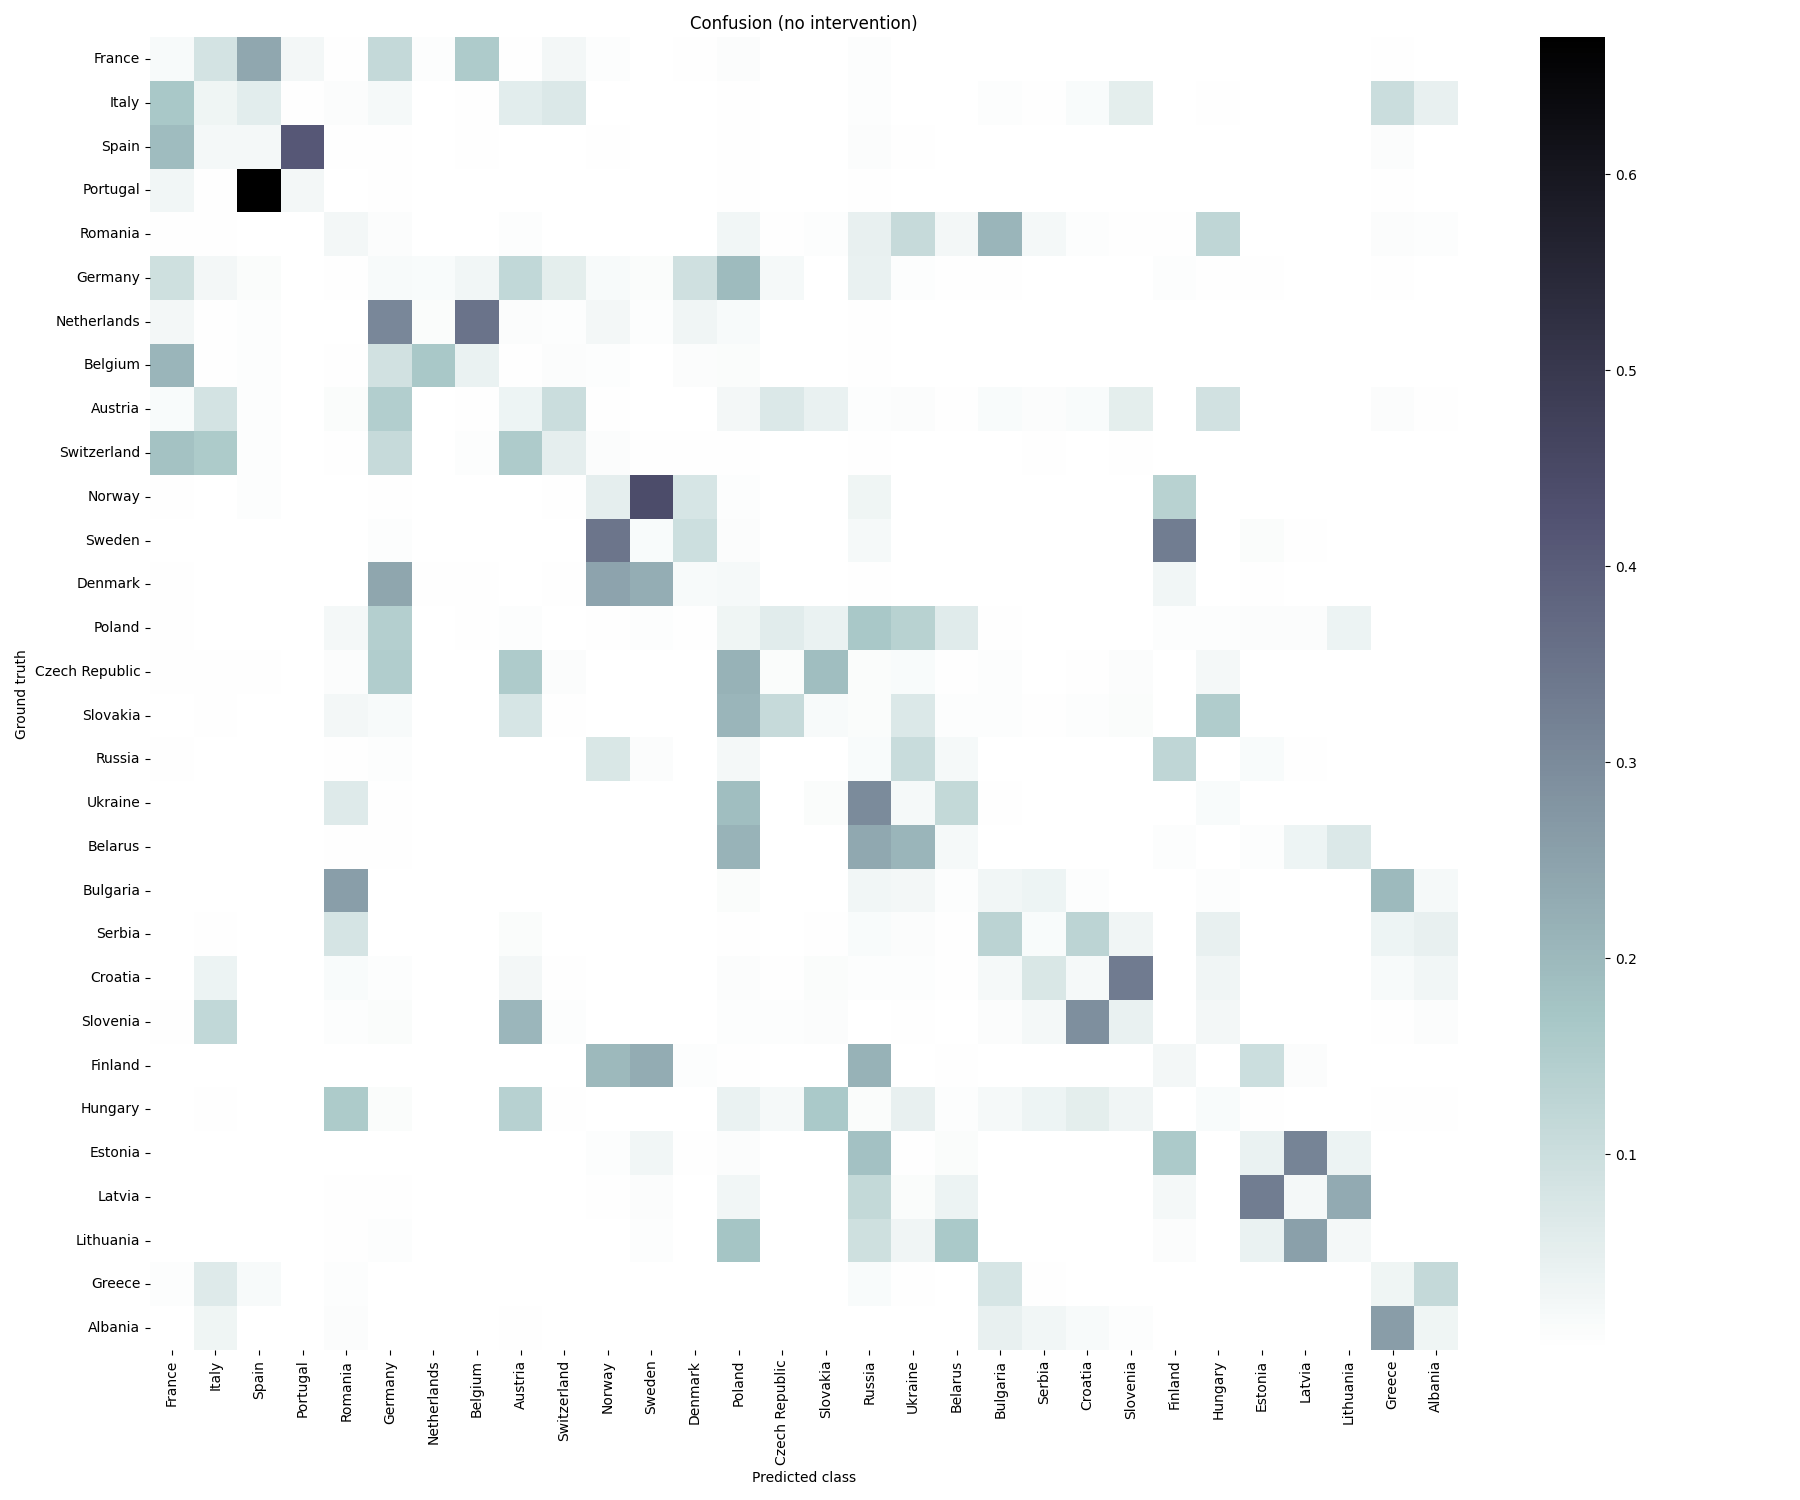

In [7]:
# Show the heatmap of the confusion matrix, with an extra column that aggregates the mass on task-unrelated tokens. 

from IPython.display import Image, display
with open(os.path.join(artifact_dir, 'confusion_heatmap.png')) as f:
    display(Image(filename=f.name))

For Gemma 3 27B-PT, the confusion matrix shows the model is concentrated on a handful of frequently-correct neighbors, with a long tail of mistakes biased toward geographically-plausible countries — consistent with the model carrying a coherent geographic representation that is more accurate than the strict baseline score implies (584 prompts have ≥1 valid neighbor; ground-truth uses the primary canonical neighbor).

## Layer localization

Now that we know Gemma 3 27B-PT solves the task, we ask **where** in the residual stream the answer-country variable is encoded.
The `locate` analysis patches activations from counterfactual inputs at each (layer, token_position) cell and measures how well the intervention recovers the expected causal effect.
See the `locate` demo notebook [[link]] for the full walkthrough; here we use the same config as the country_borders reference run.

In [8]:
# Define the locate config, save and load for printing
#
# Gemma 3 27B has 62 transformer layers — wider sweep than the 32-layer
# Llama-8B baseline.

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_4b_pt
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: country
  target_variable: country

locate:
  method: interchange
  mode: pairwise
  layers: [0, 6, 12, 18, 24, 30]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'country_borders_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('country_borders_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /workspace/causalab/causalab/configs/runners/demos/country_borders_locate_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: country_borders
  max_new_tokens: 1
  intervention_metric: string_match
  colormap: viridis
  colormap2: null
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: country
  target_variable: country
  color_by_dim: 0
  reference_source: empirical
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range: null
    grid_resolution: null
    bin_positions: null
model:
  id: gemma3_4b_pt
  name: google/gemma-3-4b-pt
  device: auto
  dtype: bfloat16
  eager_attn: false
  use_chat_template: false
  model_class: Gemma3ForCausalLM
  slurm:
    gpus: 1
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchange
  batch_size: 32
  layers:
 

In [9]:
# Run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_locate_demo"],
    cwd=project_root,
)

[2026-05-21 12:36:38,653][__main__][INFO] - === Step: locate (locate) ===
[2026-05-21 12:36:42,683][causalab.neural.activations.intervenable_model][INFO] - Registered Gemma3ForCausalLM with pyvene (reusing Gemma2 mappings).
[2026-05-21 12:36:43,107][causalab.io.pipelines][INFO] - Loading model: google/gemma-3-4b-pt (device=cuda)


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 16.83it/s]


[2026-05-21 12:36:47,812][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['country']
[2026-05-21 12:36:47,812][causalab.analyses.locate.main][INFO] - === Locate: target_variable=country ===
[2026-05-21 12:36:47,917][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=country)
[2026-05-21 12:36:47,922][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 36.7%
[2026-05-21 12:36:47,923][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([30, 30])
[2026-05-21 12:36:47,924][causalab.methods.interchange.layer_scan][INFO] - Collecting counterfactual output distributions...


Pairwise layer scan: 100%|██████████| 18/18 [01:17<00:00,  4.30s/it]


[2026-05-21 12:38:12,591][causalab.analyses.locate.main][INFO] - country: best cell = (layer=6, position=country), score=0.3385
[2026-05-21 12:38:12,694][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=country)
[2026-05-21 12:38:28,488][causalab.analyses.locate.main][INFO] - Single-pair trace saved to artifacts/country_borders/gemma3_4b_pt/locate/interchange/single_pair_trace.json
[2026-05-21 12:38:29,006][causalab.analyses.locate.main][INFO] - Locate analysis complete. Output in artifacts/country_borders/gemma3_4b_pt/locate/interchange


CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_locate_demo'], returncode=0)

In [10]:
locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)
print(f'Locate artifact directory: {locate_artifact_dir}\n')
print('Contents:', sorted(os.listdir(locate_artifact_dir)))

Locate artifact directory: /workspace/causalab/artifacts/country_borders/gemma3_4b_pt/locate/interchange

Contents: ['country', 'metadata.json', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.png']


Base prompt:           Q: Which country lies to the north of France?
A:
Counterfactual prompt: Q: Which country lies to the north of Croatia?
A:



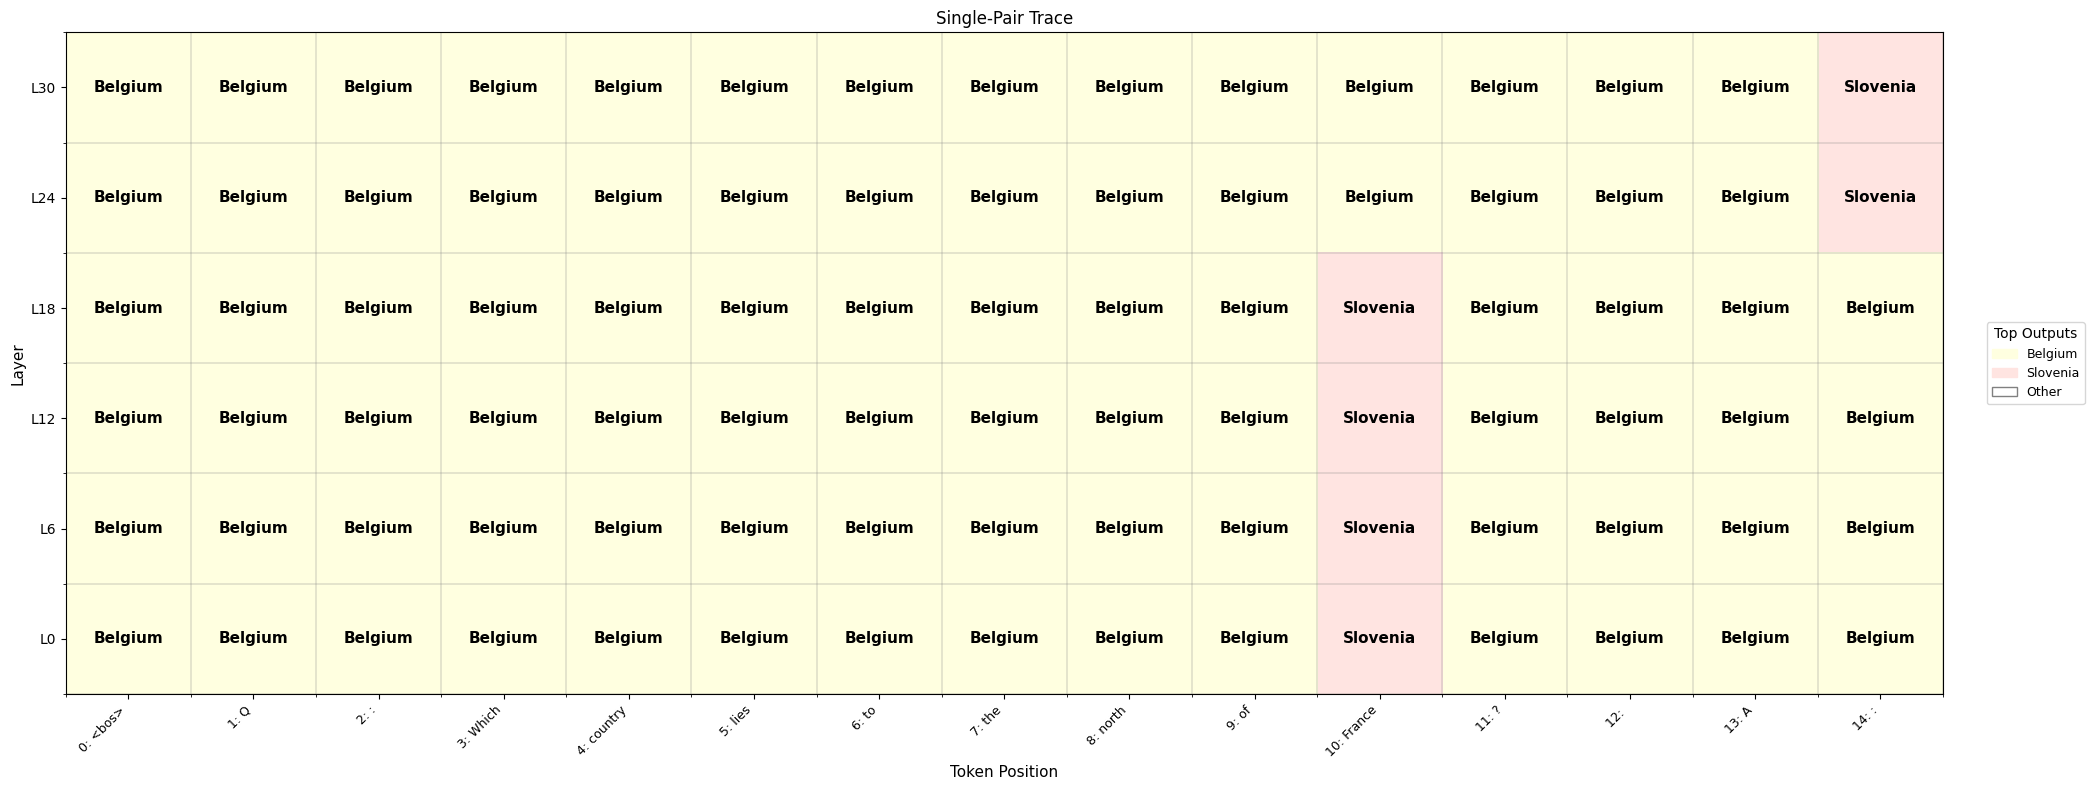

In [11]:
# Show the single-pair trace: what the model outputs at every (layer, token_position) when one counterfactual pair is patched.
# Look for where the signal "hops" from the input token to the last token across layers.

import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(locate_artifact_dir, 'single_pair_trace.json')
with open(trace_path) as f:
    trace_data = json.load(f)

print(f"Base prompt:           {trace_data['prompt']}")
print(f"Counterfactual prompt: {trace_data['counterfactual_prompt']}\n")

plot_single_pair_trace_heatmap(trace_data, figure_format='png')


--- country ---


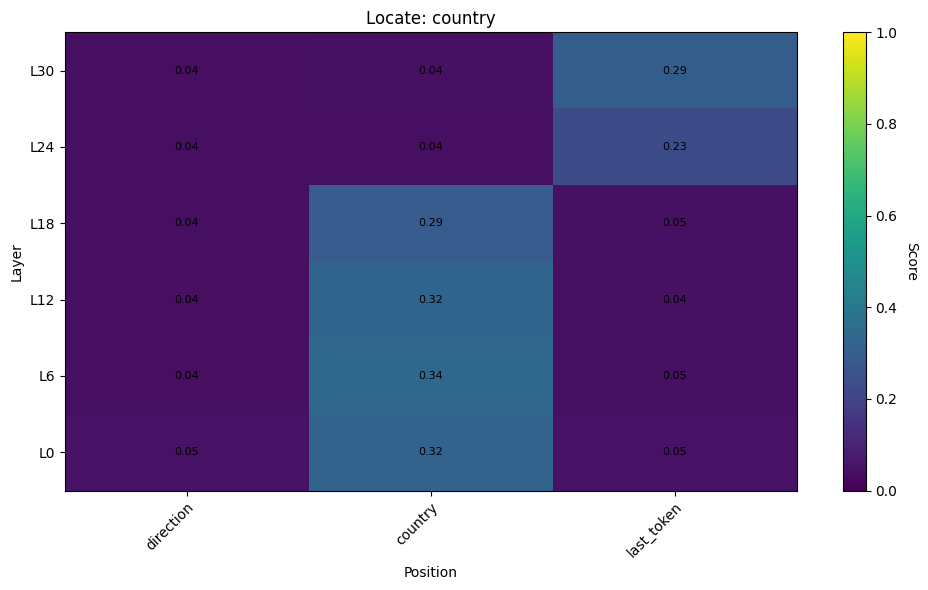

In [12]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

The heatmap localizes the answer-country variable to a small region of (layer, token_position) cells. Information about the queried country enters early at the country token and is routed toward the last token, where the unembedding reads it out. This gives us the (layer, position) target for the next RQ — finding the low-dimensional subspace within that cell.

Now, we're specifically interested in patching centroids. Before, we were defining (base, source) counterfactual pairs and checking whether the patch successfully steered the model from base to source prediction. 
Instead, we now compute one centroid per *answer country* (averaging over all (entity, direction) prompts whose primary neighbor is that country) and check whether intervening with a source centroid robustly steers the answer, regardless of the specific input. This averages out information about the entity and direction, since many (entity, direction) cells share the same answer country (e.g. France can be the answer for Spain→NE, Belgium→S, Germany→W, ...).

We're switching to centroid mode and resample all variables.


In [13]:
# Defining the centroid patching config.

locate_config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_4b_pt
  - /analysis/locate
  - _self_
task:
  enumerate_all: true # Enumerate all examples in the training set, test = []
  intervention_metric: string_match
  resample_variable: all # <-- changing to all variables, since we don't use counterfactual pairs anyways, the centroids will be our counterfactual pairs.
  target_variable: country

locate:
  method: interchange
  mode: centroid # <-- changing to centroid mode
  layers: [0, 6, 12, 18, 24, 30]
  n_steer: 16
  visualization:
    figure_format: png
"""

from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(locate_config_yaml, 'country_borders_locate_demo')
print(f'Written to {path}\n')

cfg = load_runner_config('country_borders_locate_demo')
print(f'Full hydra config:\n')
print(OmegaConf.to_yaml(cfg))

Written to /workspace/causalab/causalab/configs/runners/demos/country_borders_locate_demo.yaml

Full hydra config:

seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: country_borders
  max_new_tokens: 1
  intervention_metric: string_match
  colormap: viridis
  colormap2: null
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: country
  color_by_dim: 0
  reference_source: empirical
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range: null
    grid_resolution: null
    bin_positions: null
model:
  id: gemma3_4b_pt
  name: google/gemma-3-4b-pt
  device: auto
  dtype: bfloat16
  eager_attn: false
  use_chat_template: false
  model_class: Gemma3ForCausalLM
  slurm:
    gpus: 1
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchange
  batch_size: 32
  layers:
  - 0

In [14]:
# Re-run the locate analysis
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_locate_demo"],
    cwd=project_root,
)

[2026-05-21 12:38:35,258][__main__][INFO] - === Step: locate (locate) ===
[2026-05-21 12:38:39,356][causalab.neural.activations.intervenable_model][INFO] - Registered Gemma3ForCausalLM with pyvene (reusing Gemma2 mappings).
[2026-05-21 12:38:39,783][causalab.io.pipelines][INFO] - Loading model: google/gemma-3-4b-pt (device=cuda)


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 17.28it/s]


[2026-05-21 12:38:44,478][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['country']
[2026-05-21 12:38:44,478][causalab.analyses.locate.main][INFO] - === Locate: target_variable=country ===
[2026-05-21 12:38:44,577][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=all)
[2026-05-21 12:38:44,582][causalab.analyses.locate.run_interchange][INFO] - Loaded base accuracy from baseline: 36.7%
[2026-05-21 12:38:44,583][causalab.analyses.locate.run_interchange][INFO] - Loaded ref_dists from baseline: torch.Size([30, 30])


Centroid layer scan: 100%|██████████| 18/18 [01:01<00:00,  3.41s/it]


[2026-05-21 12:39:46,446][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/gemma3_4b_pt/locate/interchange/country/L0/Plast_token/patched_dim0.png
[2026-05-21 12:39:46,446][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/country_borders/gemma3_4b_pt/locate/interchange/country/L0/Plast_token/patched_dim0.png
[2026-05-21 12:39:46,897][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/gemma3_4b_pt/locate/interchange/country/L0/Pcountry/patched_dim0.png
[2026-05-21 12:39:46,897][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/country_borders/gemma3_4b_pt/locate/interchange/country/L0/Pcountry/patched_dim0.png
[2026-05-21 12:39:47,348][causalab.io.plots.plot_utils][INFO] - Saved figure to artifacts/country_borders/gemma3_4b_pt/locate/interchange/country/L0/Pdirection/patched_dim0.png
[2026-05-21 12:39:47,348][causalab.analyses.p

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_locate_demo'], returncode=0)


--- country ---


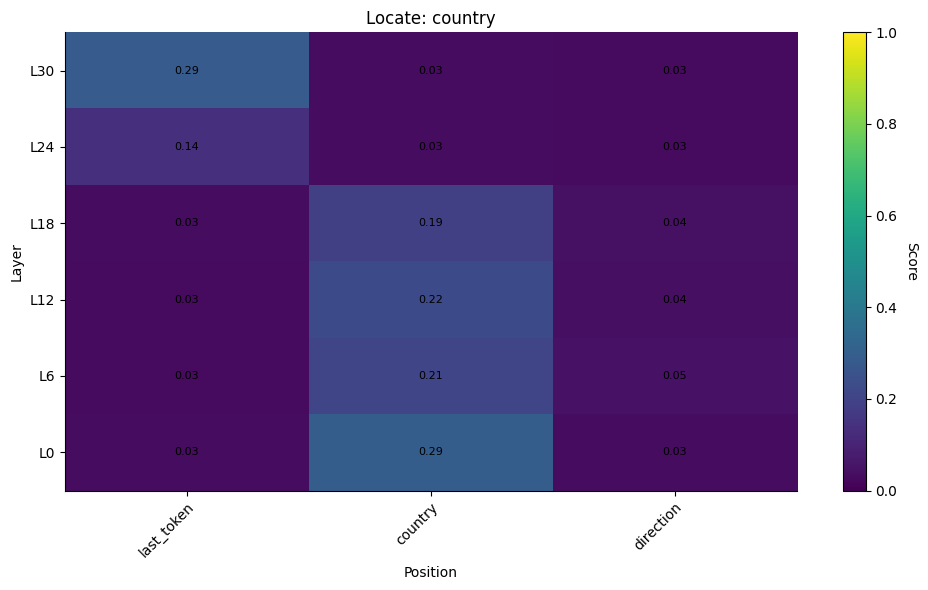

In [15]:
# Show the per-variable (layer x token_position) score heatmap. The brightest cell is the most localized site for the variable.

from glob import glob
from IPython.display import Image, display

locate_artifact_dir = os.path.join(
    project_root, cfg.experiment_root, 'locate',
    cfg.locate.method,
)

for var_name in sorted(os.listdir(locate_artifact_dir)):
    var_dir = os.path.join(locate_artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, 'heatmap.png'))
    if matches:
        print(f'\n--- {var_name} ---')
        display(Image(filename=matches[0]))

We've learned that centroid intervention works at the final token position at layer 28 (the canonical site studied in the original geometry result). Let's fix our following investigation to this site in the model.
Next, we want to identify whether a low-dimensional subspace captures most variance.


## Subspace localization

"Subspace that captures most variance" can mean two (or more?) things each requiring its own tool: 
- **Input variance:** Subspace that captures most variance of activations for all inputs --> PCA
- **Output variance:** Subspace that is most causally relevant to flip a model prediction from the base answer to a counterfactual source answer.

In the end we are concerned with steering model behavior, so causal efficacy is highly relevant and DAS is a suitable tool.
However, in our current approach we are patching centroids over all inputs and don't define counterfactual pairs, so PCA is a natural choice for subspace identification with this approach.

`country_borders` task with Gemma 3 27B-PT.

In [61]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_4b_pt
  - /analysis/subspace
  - _self_
task:
  enumerate_all: true # training on all possible examples, test = train
  target_variable: country

subspace:
  method: pca
  # Wider sweep on Gemma 3 27B (62 layers). The combined-R^2 vs layer curve
  # below pinpoints the peak; downstream activation_manifold/path_steering
  # cells lock onto whichever layer wins.
  layers: [33]
  k_features: 32
  token_positions: [last_token]
  visualization:
    figure_format: png
"""


save_runner_config(config_yaml, 'country_borders_subspace_demo')
cfg = load_runner_config('country_borders_subspace_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

Full hydra config:
 seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: country_borders
  max_new_tokens: 1
  intervention_metric: string_match
  colormap: viridis
  colormap2: null
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: country
  color_by_dim: 0
  reference_source: empirical
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range: null
    grid_resolution: null
    bin_positions: null
model:
  id: gemma3_4b_pt
  name: google/gemma-3-4b-pt
  device: auto
  dtype: bfloat16
  eager_attn: false
  use_chat_template: false
  model_class: Gemma3ForCausalLM
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: pca
  k_features: 32
  batch_size: 32
  component_type: residual_stream
  layers:
  - 33
  token_positions:
  - last_t

In [62]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_subspace_demo"],
    cwd=project_root
)

[2026-05-21 12:52:37,047][__main__][INFO] - === Step: subspace (subspace) ===
[2026-05-21 12:52:41,113][causalab.neural.activations.intervenable_model][INFO] - Registered Gemma3ForCausalLM with pyvene (reusing Gemma2 mappings).
[2026-05-21 12:52:41,121][__main__][INFO] - Running analysis: subspace | target_variable: country
[2026-05-21 12:52:41,363][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=all)
[2026-05-21 12:52:41,790][causalab.io.pipelines][INFO] - Loading model: google/gemma-3-4b-pt (device=cuda)


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 18.55it/s]


[2026-05-21 12:52:46,400][causalab.analyses.subspace.pca][INFO] - Computing PCA with k=32...


[2026-05-21 12:52:50,825][causalab.analyses.subspace.pca][INFO] - PCA variance explained: ['38.7%', '22.8%', '6.9%', '5.6%', '3.7%', '2.6%', '1.9%', '1.4%', '1.2%', '1.0%', '0.8%', '0.7%', '0.7%', '0.6%', '0.5%', '0.5%', '0.4%', '0.4%', '0.4%', '0.4%', '0.3%', '0.3%', '0.3%', '0.3%', '0.3%', '0.3%', '0.3%', '0.2%', '0.2%', '0.2%', '0.2%', '0.2%'], total: 94.2%
[2026-05-21 12:52:51,029][causalab.methods.spline.builders][INFO] - Computed 30 centroids from 960 samples (params: ['country_0', 'country_1'])
[2026-05-21 12:52:51,516][causalab.io.plots.plot_3d_interactive][INFO] - Saved artifacts/country_borders/gemma3_4b_pt/subspace/pca_k32/country/visualization/features_3d.html
[2026-05-21 12:52:51,516][causalab.analyses.subspace._visualization][INFO] - Saved features_3d.html to artifacts/country_borders/gemma3_4b_pt/subspace/pca_k32/country/visualization
[2026-05-21 12:52:51,532][causalab.methods.spline.builders][INFO] - Computed 30 centroids from 960 samples (params: ['country_0', 'country

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_subspace_demo'], returncode=0)

In [63]:
subspace_artifact_dir = os.path.join(
  project_root, cfg.experiment_root, 'subspace',
  f"{cfg.subspace.method}_k{cfg.subspace.k_features}",
  cfg.task.target_variable,
)   
vis_dir = os.path.join(subspace_artifact_dir, 'visualization')
print(f'Visualization directory: {vis_dir}')
print('Contents:', sorted(os.listdir(vis_dir)))

Visualization directory: /workspace/causalab/artifacts/country_borders/gemma3_4b_pt/subspace/pca_k32/country/visualization
Contents: ['features_2d.png', 'features_3d.html', 'features_3d.png', 'features_variance.png']


### Variance explained by the PCA subspace

Each bar shows the **cumulative** variance explained by the first k principal components,
as a fraction of the **total variance of the full embedding space** — the denominator is
the sum of all singular values squared, not just the k-component subspace.
A steep early rise means the representation is intrinsically low-dimensional.
The dashed line marks how much total variance the chosen k_features subspace retains.


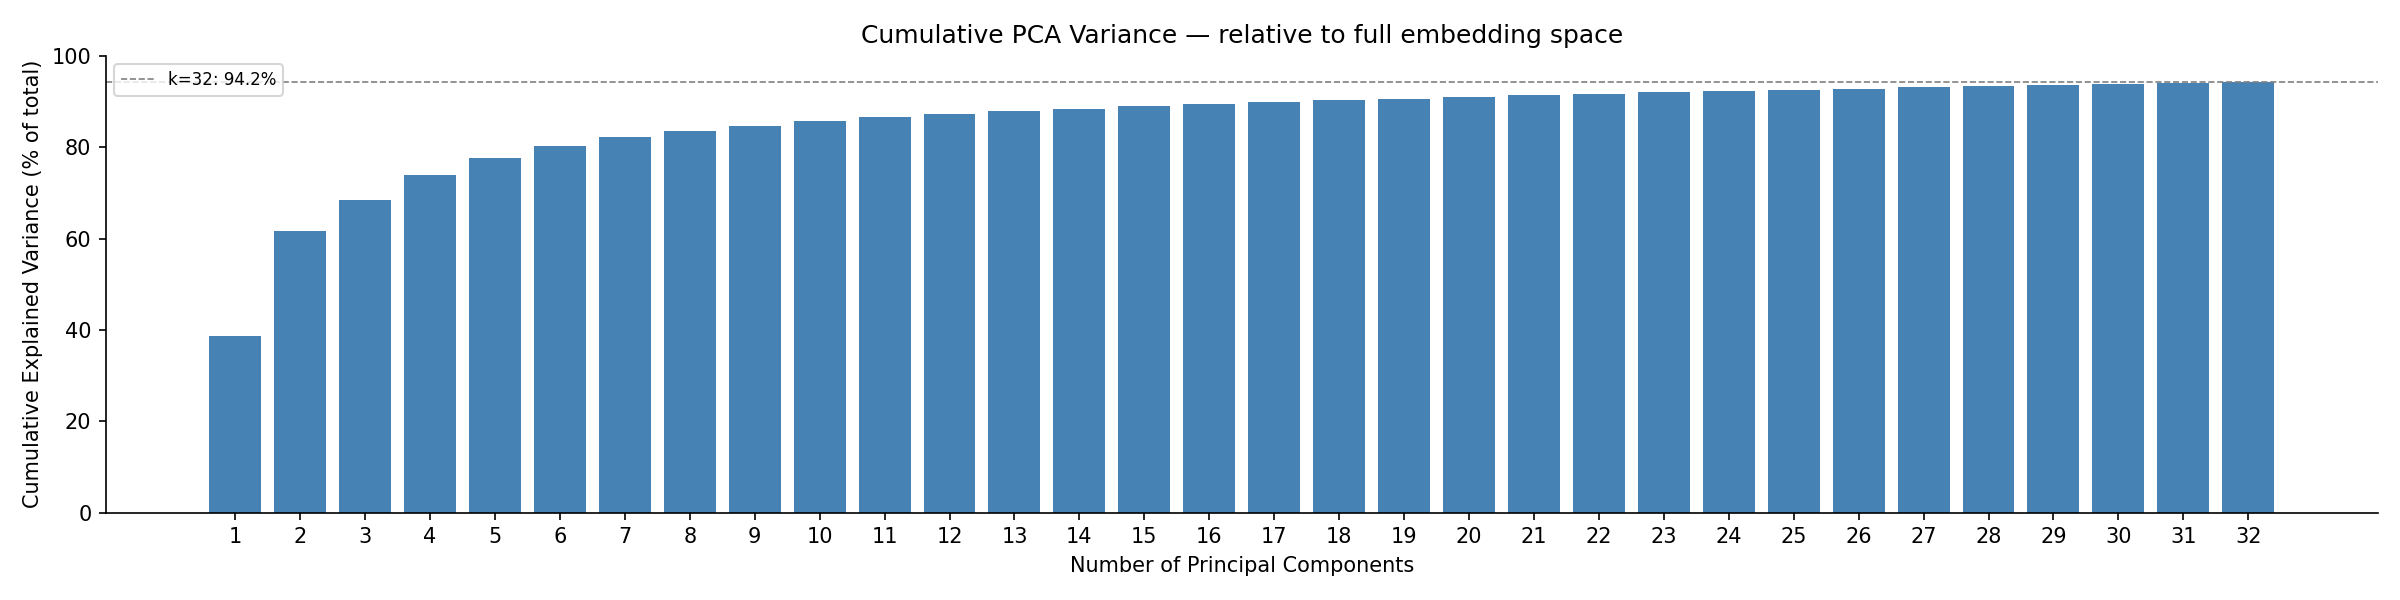

In [64]:
# Cumulative explained variance vs. number of PCs
display(Image(filename=os.path.join(vis_dir, 'features_variance.png')))

The first three PCs typically capture most of the structure (on Llama-3.1-8B base the cumulative was ≈53% / 22% / 9% ≈ 84%; Gemma 3 27B-PT has a similar shape with slightly different magnitudes), so `k_features=32` is comfortably above the elbow.

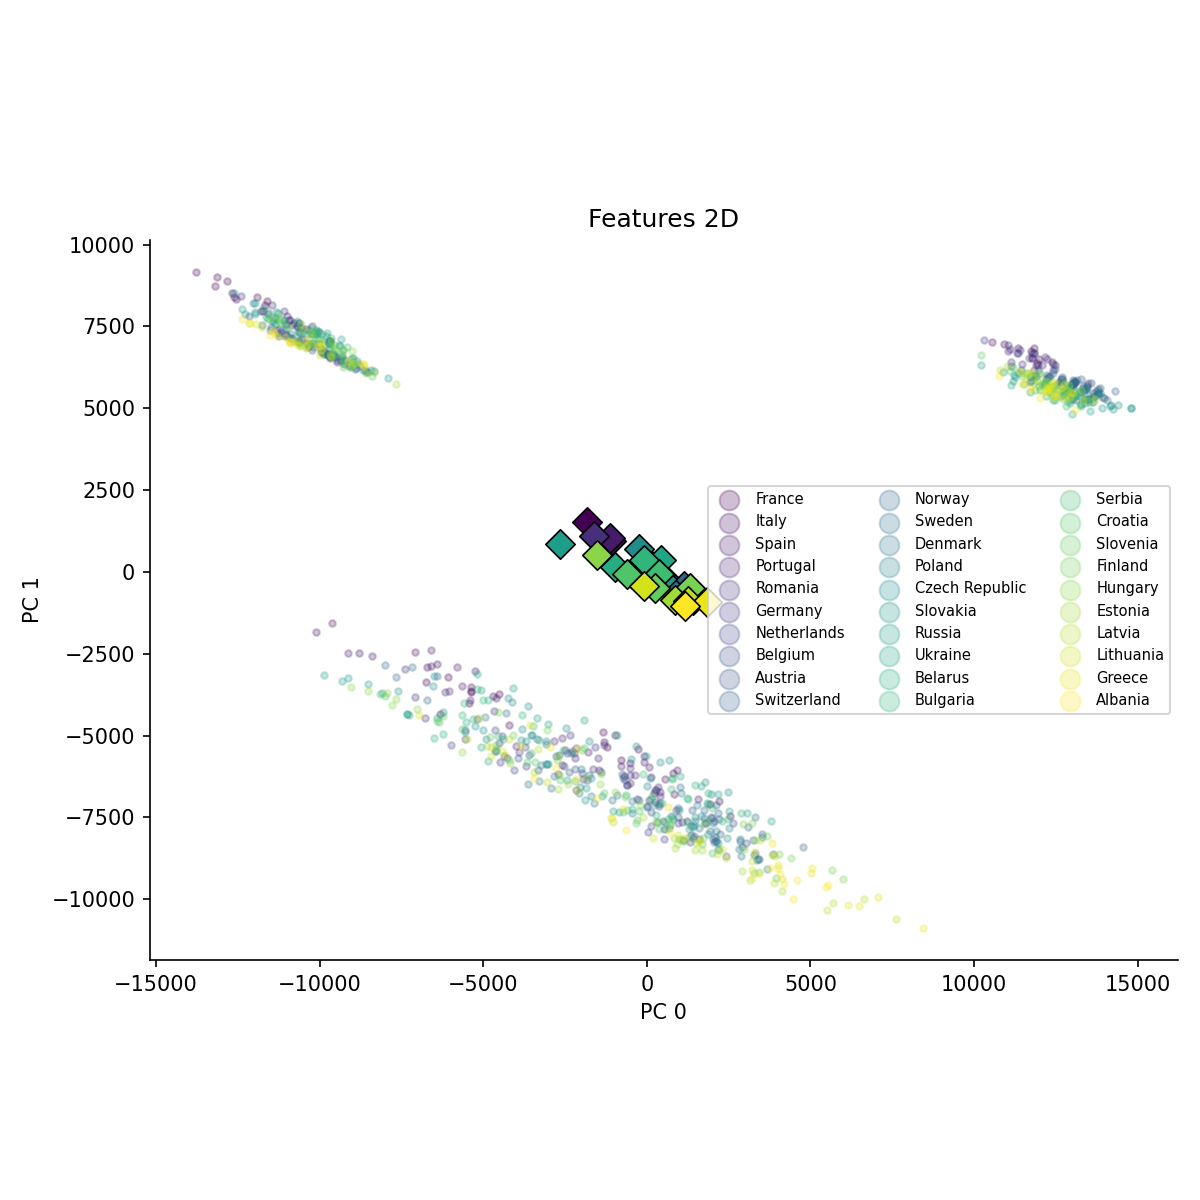

In [65]:
# 2D PCA scatter: training examples colored by weekday
display(Image(filename=os.path.join(vis_dir, 'features_2d.png')))

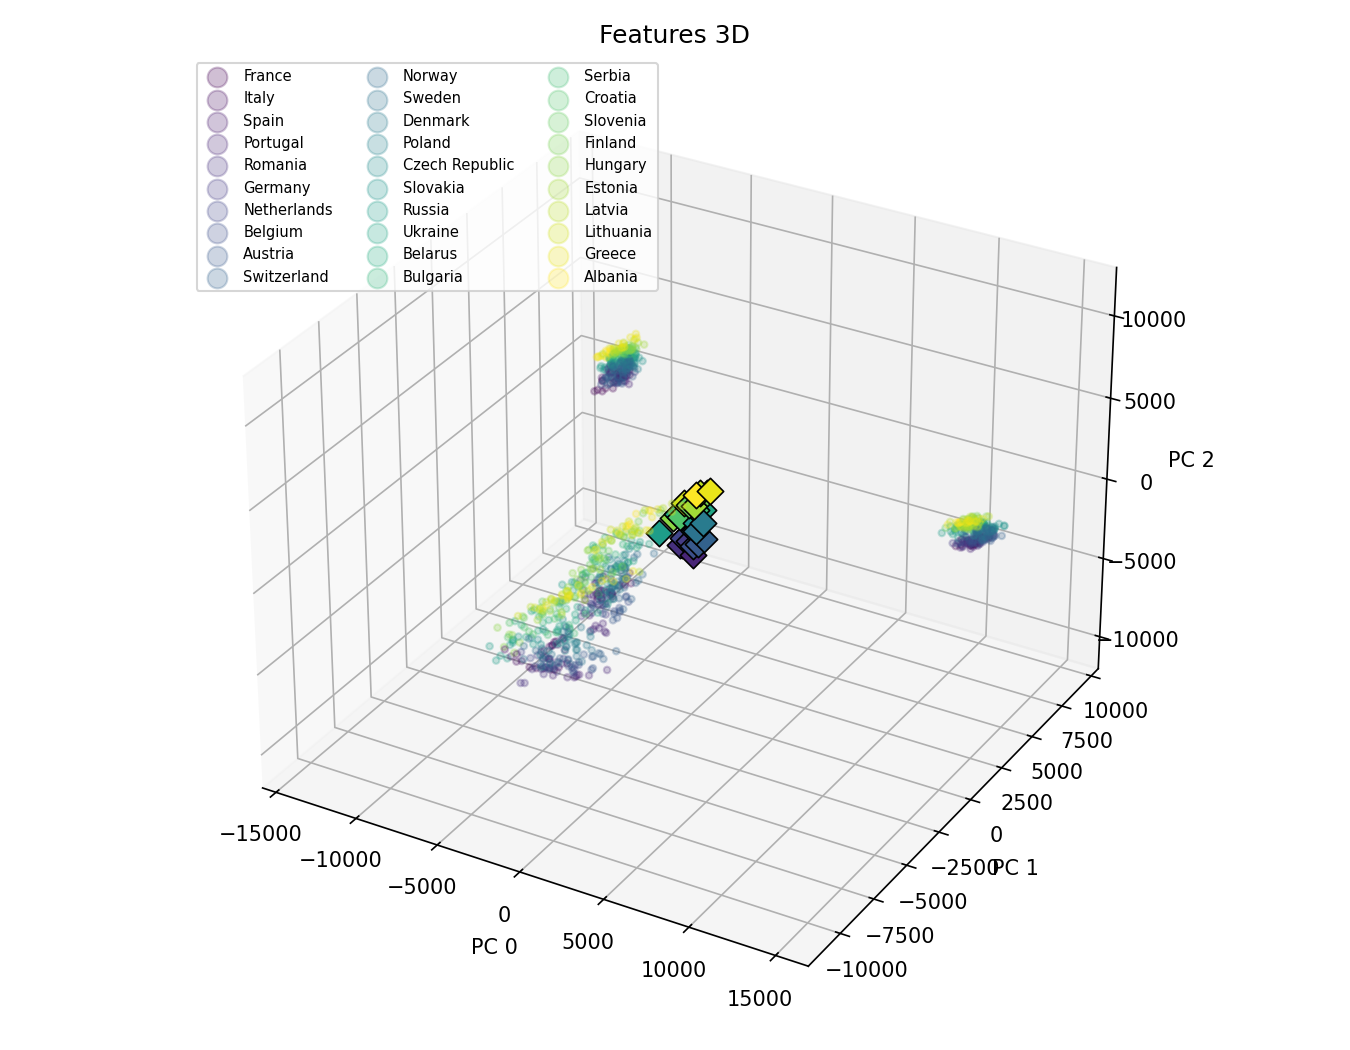

In [66]:
# Static 3D PCA scatter (matplotlib): PC0 x PC1 x PC2
display(Image(filename=os.path.join(vis_dir, 'features_3d.png')))

PC0: R^2=0.889
PC1: R^2=0.836
PC2: R^2=0.044


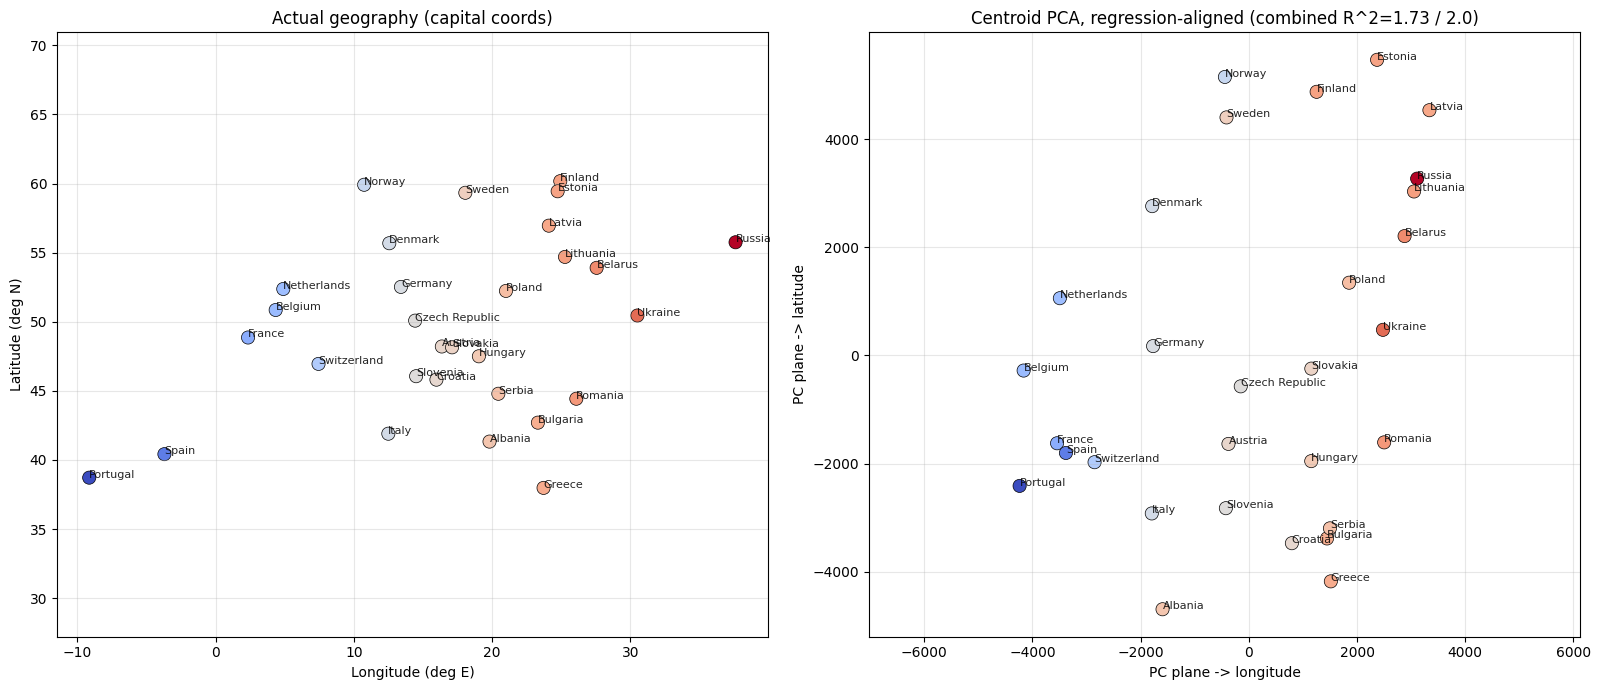

In [67]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from safetensors.torch import load_file
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from causalab.tasks.country_borders import COUNTRIES, NEIGHBOR_OF, LAT_LON_OF

try:
  from adjustText import adjust_text
except ImportError:
  adjust_text = None

# 1. PCA-32 features at the chosen layer + row-aligned train dataset.
features = load_file(
  os.path.join(subspace_artifact_dir, "features", "raw_features.safetensors")
)["features"].float().numpy()
with open(os.path.join(subspace_artifact_dir, "train_dataset.json")) as f:
  rows = json.load(f)

# 2. Group by ANSWER country (primary neighbor); drop invalid cells.
by_answer: dict[str, list[int]] = {}
for i, r in enumerate(rows):
  key = (r["input"]["country"], r["input"]["direction"])
  if key in NEIGHBOR_OF:
      by_answer.setdefault(NEIGHBOR_OF[key][0], []).append(i)
names = [c for c in COUNTRIES if c in by_answer]
centroids = np.stack([features[by_answer[c]].mean(0) for c in names])
lats = np.array([LAT_LON_OF[c][0] for c in names])
lons = np.array([LAT_LON_OF[c][1] for c in names])
geo = np.column_stack([lats, lons])

# 3. PCA(3) over centroids; print per-PC R^2 with geography.
P = PCA(n_components=3).fit_transform(centroids)
for k in range(3):
  r2 = LinearRegression().fit(geo, P[:, k]).score(geo, P[:, k])
  print(f"PC{k}: R^2={r2:.3f}")
  
# 4. Regression-aligned axes.
east  = LinearRegression().fit(P[:, :2], lons).coef_
north = LinearRegression().fit(P[:, :2], lats).coef_
east  /= np.linalg.norm(east); north /= np.linalg.norm(north)
disp_x = P[:, :2] @ east
disp_y = P[:, :2] @ north
combined_r2 = sum(
  LinearRegression().fit(geo, P[:, k]).score(geo, P[:, k]) for k in range(2)
)

# 5. Side-by-side plot, colored by longitude.
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
panels = [
  (lons, lats, "Longitude (deg E)", "Latitude (deg N)",
   "Actual geography (capital coords)"),
  (disp_x, disp_y, "PC plane -> longitude", "PC plane -> latitude",
   f"Centroid PCA, regression-aligned (combined R^2={combined_r2:.2f} / 2.0)"),
]
for axi, (xs, ys, xl, yl, title) in zip(ax, panels):
  axi.scatter(xs, ys, s=90, c=lons, cmap="coolwarm",
              edgecolors="black", linewidths=0.5)
  texts = [axi.annotate(n, (x, y), fontsize=8, alpha=0.85)
           for n, x, y in zip(names, xs, ys)]
  if adjust_text is not None:
      adjust_text(texts, ax=axi,
                  arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
                  expand_points=(1.2, 1.4))
  axi.set(xlabel=xl, ylabel=yl, title=title)
  axi.set_aspect("equal", adjustable="datalim")
  axi.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
# Are each country's K nearest centroid neighbors actually geographic neighbors?
from sklearn.metrics.pairwise import cosine_distances
from causalab.tasks.country_borders import NEIGHBOR_OF

# centroids and names already in scope from cell 30
D = cosine_distances(centroids)  # (30, 30)
K = 3

# Geographic neighbors per country: take all directions' primary neighbors.
geo_neighbors = {c: set() for c in names}
for (country, _direction), targets in NEIGHBOR_OF.items():
  if country in geo_neighbors:
      geo_neighbors[country].add(targets[0])

centroid_neighbor_hit = 0
total = 0
for i, c in enumerate(names):
  # K nearest centroid neighbors (excluding self)
  nn = [names[j] for j in np.argsort(D[i])[1:K+1]]
  geo = geo_neighbors[c]
  if not geo:  # skip countries with no defined neighbors in-set
      continue
  centroid_neighbor_hit += sum(1 for n in nn if n in geo)
  total += K

# Random baseline: K out of 29 possible non-self picks per country.
mean_neighbors = np.mean([len(s) for s in geo_neighbors.values() if s])
chance = mean_neighbors / 29 * K
print(f"Centroid-NN ∩ geo-neighbor:  hit_rate = {centroid_neighbor_hit/total:.3f}  "
    f"(chance ≈ {chance/K:.3f})")

Centroid-NN ∩ geo-neighbor:  hit_rate = 0.822  (chance ≈ 0.128)


## Activation manifold fitting

We'll use a thin-plate spline parameterized by capital `[lat, lon]` (the task exposes this via the `country` variable's embedding) to fit a smooth 2-D manifold through the 30 country centroids.


In [116]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_27b_pt
  - /analysis/activation_manifold
  - _self_
task:
  target_variable: country
activation_manifold:
  manifold_intrinsic_coords: parameter
  method: spline
  smoothness: 0.0
  subspace: pca_k32
  k_features: 32
  skip_decoding_eval: false
  # Set this to the layer that wins the subspace combined-R^2 curve above.
  # Default placeholder = 48 (mid-late, analog of L24/32 on Llama-8B).
  layers: [60]
  token_positions: [last_token]
  visualization:
    figure_format: png
""" 

save_runner_config(config_yaml, 'country_borders_activation_manifold_demo')
cfg = load_runner_config('country_borders_activation_manifold_demo')
print(f'Full hydra config:\n', OmegaConf.to_yaml(cfg))

Full hydra config:
 seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: country_borders
  max_new_tokens: 1
  intervention_metric: string_match
  colormap: viridis
  colormap2: null
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: country
  color_by_dim: 0
  reference_source: empirical
  distance_function: hellinger
  isometry:
    distance_function: ${task.distance_function}
    grid_range: null
    grid_resolution: null
    bin_positions: null
model:
  id: gemma3_27b_pt
  name: google/gemma-3-27b-pt
  device: auto
  dtype: bfloat16
  eager_attn: false
  use_chat_template: false
  model_class: Gemma3ForCausalLM
  slurm:
    gpus: 2
activation_manifold:
  _name_: activation_manifold
  _subdir: ${.method}_s${.smoothness}
  _output_dir: ${experiment_root}/activation_manifold/${._subdir}
  method: spline
  smoothness: 0.0
  spline_method: auto
  intrinsic_dim: null
  n_grid: 21
 

In [117]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_activation_manifold_demo"],
    cwd=project_root,
)

[2026-05-21 12:13:54,470][__main__][INFO] - === Step: activation_manifold (activation_manifold) ===
[2026-05-21 12:13:58,517][causalab.neural.activations.intervenable_model][INFO] - Registered Gemma3ForCausalLM with pyvene (reusing Gemma2 mappings).
[2026-05-21 12:13:58,520][__main__][INFO] - Running analysis: activation_manifold | target_variable: country
[2026-05-21 12:13:58,762][causalab.runner.helpers][INFO] - Exhaustive enumeration: 960 unique input combinations (resample_variable=all)
[2026-05-21 12:13:58,762][causalab.analyses.activation_manifold.main][INFO] - Dataset generation: 0.2s
[2026-05-21 12:13:59,171][causalab.io.pipelines][INFO] - Loading model: google/gemma-3-27b-pt (device=cuda)


Loading checkpoint shards: 100%|██████████| 12/12 [00:00<00:00, 117.20it/s]


[2026-05-21 12:14:09,700][causalab.analyses.activation_manifold.main][INFO] - Model loading: 10.9s
[2026-05-21 12:14:09,704][causalab.analyses.activation_manifold.main][INFO] - === Manifold for subspace pca_k32 ===
[2026-05-21 12:14:12,312][causalab.analyses.subspace.loading][INFO] - Loaded PCA rotation from artifacts/country_borders/gemma3_27b_pt/subspace/pca_k32/country/rotation.safetensors
[2026-05-21 12:14:12,396][causalab.analyses.activation_manifold.main][INFO] - Loaded saved subspace dataset: 960 examples
[2026-05-21 12:14:12,397][causalab.analyses.activation_manifold.main][INFO] - Loaded ref_dists from baseline
[2026-05-21 12:14:12,399][causalab.analyses.activation_manifold.fitting_pipeline][INFO] - Auto-detected intrinsic_dim=1
[2026-05-21 12:14:12,399][causalab.analyses.activation_manifold.fitting_pipeline][INFO] - Starting manifold fitting pipeline: k=32, d=1, method=spline
[2026-05-21 12:14:12,399][causalab.analyses.activation_manifold.fitting_pipeline][INFO] - Step 1: Fitt

Error executing job with overrides: []
Traceback (most recent call last):
  File "/workspace/causalab/causalab/runner/run_exp.py", line 204, in main
    _run_steps(cfg)
  File "/workspace/causalab/causalab/runner/run_exp.py", line 166, in _run_steps
    _run_analysis_for_variables(
  File "/workspace/causalab/causalab/runner/run_exp.py", line 110, in _run_analysis_for_variables
    analysis_fn(cfg)
  File "/workspace/causalab/causalab/analyses/activation_manifold/main.py", line 366, in main
    pipeline_result = run_manifold_fitting_pipeline(fitting_config)
  File "/workspace/causalab/causalab/analyses/activation_manifold/fitting_pipeline.py", line 288, in run_manifold_fitting_pipeline
    manifold_result = train_spline_manifold(
  File "/workspace/causalab/causalab/methods/spline/train.py", line 376, in train_spline_manifold
    raise ValueError(
ValueError: intrinsic_dim=1 but got 2 parameters. For spline method, intrinsic_dim must match number of causal parameters.

Set the environm

CompletedProcess(args=['bash', 'scripts/run_exp.sh', 'country_borders_activation_manifold_demo'], returncode=1)

In [118]:
# Find the manifold_3d.png — artifact dir is nested under activation_manifold/
from glob import glob

manifold_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'visualization', 'manifold_3d.png',
), recursive=True))
print('Found:', manifold_pngs)

Found: []


In [119]:
# Static 3D manifold: scatter colored by weekday + fitted spline curve
display(Image(filename=manifold_pngs[0]))

IndexError: list index out of range

Because the manifold is a continuous 2-D spline, we can steer the model to any (lat, lon) point on it —
intrinsic-space positions between any two centroids (e.g. Spain → Russia, passing near Italy/Austria/Ukraine)
give us geographic steering targets across the European map. This manifold-traversal
evaluation is now produced by the **`path_steering`** analysis (the natural follow-up to
`activation_manifold`); its heatmaps show how each country token's output probability
evolves as we walk the geodesic.
Re-run with `path_steering` in the runner config to regenerate this section.


In [ ]:
# Continuous manifold steering: x-axis labels show weekday names at centroid positions;
# unlabelled ticks between them are interpolated intrinsic-space positions.

steering_pngs = sorted(glob(os.path.join(
    project_root, cfg.experiment_root, 'activation_manifold',
    '**', 'manifold_steering', 'manifold_steering_dim0.png',
), recursive=True))
print('Found:', steering_pngs)

if steering_pngs:
    display(Image(filename=steering_pngs[0]))

## Path steering: geodesic vs linear

With the activation manifold fitted, we steer the model from Spain to Russia along two paths:
- **Geodesic**: follows the fitted spline in intrinsic (lat, lon) coordinates — stays on the manifold
- **Linear**: straight line between the two centroids in PCA space — cuts through embedding space

We restrict to a single far pair (Spain → Russia) to compare the output distributions produced by each path.


In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: country_borders
  - /model: gemma3_27b_pt
  - /analysis/path_steering
  - _self_
task:
  target_variable: country
path_steering:
  subspace: pca_k32
  # Include the L{layer}_{token_position} cell-segment that
  # activation_manifold writes when token_positions is set, so the loader
  # finds the spline featurizer instead of falling back to identity.
  # Must match the layer chosen in subspace/activation_manifold above.
  activation_manifold: L48_last_token/spline_s0.0
  selected_pairs: [["Spain", "Russia"]]
  path_modes: [geometric, linear]
  visualization:
    figure_format: png
"""

save_runner_config(config_yaml, 'country_borders_path_steering_demo')
cfg_ps = load_runner_config('country_borders_path_steering_demo')
print('Full hydra config:\n', OmegaConf.to_yaml(cfg_ps))

In [ ]:
subprocess.run(
    ["bash", "scripts/run_exp.sh", "country_borders_path_steering_demo"],
    cwd=project_root,
)

In [ ]:
# Path-steering artifacts are nested under <subspace>/<manifold>/<target_variable>/...
ps_out_dir = os.path.join(
    project_root, cfg_ps.experiment_root,
    'path_steering',
    cfg_ps.path_steering.subspace,
    cfg_ps.path_steering.activation_manifold,
    cfg_ps.task.target_variable,
)

In [ ]:
# 3D PCA space: geodesic (black) vs linear (gray) path from Monday to Thursday.
# The 3D plot is saved as an interactive HTML (plotly), not a static image.
from IPython.display import IFrame
path_3d_html = os.path.join(ps_out_dir, 'vis', 'paths', '3d_paths', 'Spain_Russia.html')
print(path_3d_html)
IFrame(src=path_3d_html, width='100%', height=600)

In [ ]:
# Geodesic path: output probability landscape stepping along the manifold
geo_img = os.path.join(ps_out_dir, 'vis', 'paths', 'geometric', 'pair_Spain_Russia.png')
display(Image(filename=geo_img))

In [ ]:
# Linear path: output probability landscape stepping through raw PCA space
lin_img = os.path.join(ps_out_dir, 'vis', 'paths', 'linear', 'pair_Spain_Russia.png')
display(Image(filename=lin_img))